## Notebook 01 - Switching Factor Analysis
Núria Pascual Salas

**Content:**
Characterization of LaLiga 2023-24 team playing styles through the Switching
Factor (SF):

$$\mathrm{SF} = \frac{1}{2}\, \frac{P_{\text{in}} + P_{\text{out}}}{P_{\text{passes}}},$$

where:
- $P_{\text{passes}}$: total number of pass attempts.
- $P_{\text{in}}$: number of possession gains (ball recoveries and successful interceptions).
- $P_{\text{out}}$: number of possession losses (incomplete passes, dispossessions,
and miscontrols).

**Analysis structure:**
1. SF per match and per team (continuous gradient)
2. Per-team correlation r(SF, Points)


**Outputs:**
- outputs/csv/sf_per_team.csv
- outputs/csv/sf_per_team_correlations.csv
- outputs/figures/sf_vs_points_continuous.png

**Used in:** Chapter 3, Section 3.2 (The Switching Factor).

In [1]:
from utils import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Load events and compute match-level SF

In [2]:
all_rows = []

for m_id, events in stream_matches_from_zip(zip_path, folder_laliga, "_events.json"):
    teams_in_match = list({(e['team']['id'], e['team']['name'])
                           for e in events if 'team' in e})
    
    for team_id, team_name in teams_in_match:
        if team_id not in all_teams:
            continue
        sf = calculate_match_sf(events, team_id)
        _, _, _, points = get_match_result(events, team_id)
        all_rows.append({
            'match_id':  m_id,
            'team_id':   team_id,
            'team_name': team_name,
            'sf':        sf,
            'points':    points,
        })

df_matches = pd.DataFrame(all_rows)
print(f"Total match-team observations: {len(df_matches)}")
print(f"Unique matches: {df_matches['match_id'].nunique()}")
print(f"Unique teams: {df_matches['team_id'].nunique()}")

Total match-team observations: 760
Unique matches: 380
Unique teams: 20


### 2. Aggregate to team level and correlate with points

In [8]:
team_summary = []

for team_name, group in df_matches.groupby('team_name'):
    if len(group) < 5:
        continue
    r, p = pearsonr(group['sf'], group['points'])
    team_summary.append({
        'team':         team_name,
        'mean_sf':      group['sf'].mean(),
        'std_sf':       group['sf'].std(),
        'total_points': group['points'].sum(),
        'r_sf_points':  r,
        'p_value':      p,
        'n_matches':    len(group),
    })

df_team = pd.DataFrame(team_summary).sort_values('total_points', ascending=False).reset_index(drop=True)
df_team.to_csv(f'{CSV_DIR}/sf_per_team_correlations.csv', index=False)
df_team[['team', 'mean_sf', 'total_points', 'r_sf_points']].to_csv(
    f'{CSV_DIR}/sf_per_team.csv', index=False)

print(df_team.round(3).to_string(index=False))

            team  mean_sf  std_sf  total_points  r_sf_points  p_value  n_matches
     Real Madrid    0.111   0.019            97       -0.021    0.899         38
       Barcelona    0.122   0.018            82       -0.203    0.221         38
          Girona    0.139   0.029            81        0.193    0.245         38
 Atlético Madrid    0.155   0.036            74       -0.043    0.799         38
   Athletic Club    0.198   0.039            72        0.396    0.014         38
      Real Betis    0.179   0.040            60       -0.148    0.375         38
   Real Sociedad    0.176   0.035            58        0.203    0.222         38
      Villarreal    0.163   0.038            51        0.190    0.254         38
        Valencia    0.220   0.054            49        0.040    0.812         38
Deportivo Alavés    0.243   0.039            45        0.442    0.005         38
         Osasuna    0.217   0.050            45        0.111    0.505         38
          Getafe    0.249   

### 3. Style gradient: visualise teams along the SF axis

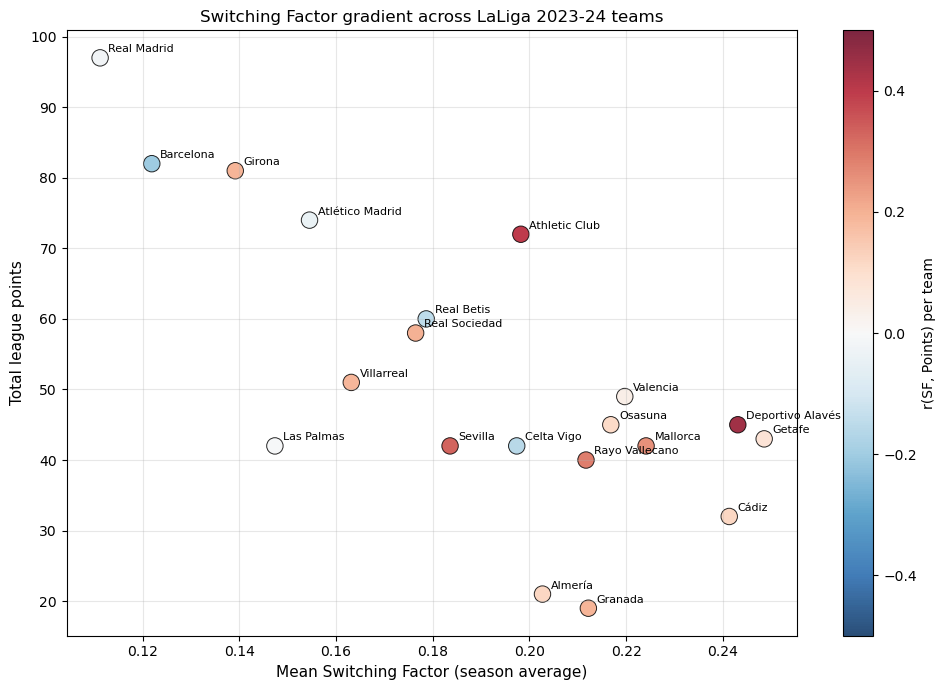

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(df_team['mean_sf'], df_team['total_points'],
                     c=df_team['r_sf_points'], cmap='RdBu_r',
                     vmin=-0.5, vmax=0.5,
                     s=140, alpha=0.85, edgecolors='black', linewidths=0.7)

for _, row in df_team.iterrows():
    ax.annotate(row['team'],
                (row['mean_sf'], row['total_points']),
                fontsize=8, textcoords='offset points', xytext=(6, 4))

ax.set_xlabel('Mean Switching Factor (season average)', fontsize=11)
ax.set_ylabel('Total league points', fontsize=11)
ax.set_title('Switching Factor gradient across LaLiga 2023-24 teams',
            fontsize=12)
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='r(SF, Points) per team')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sf_vs_points_continuous.png',
            dpi=130, bbox_inches='tight')
plt.show()

### Summary

In [10]:
print("=" * 70)
print("SUMMARY - Switching Factor Characterization")
print("=" * 70)
print()
print(f"Sample: {df_matches['match_id'].nunique()} matches, "
      f"{df_team['team'].nunique()} teams, "
      f"{len(df_matches)} team-match observations")
print()
print("--- Style gradient (per-team r(SF, Points)) ---")
print(f"  Most possession-oriented: {df_team.loc[df_team['r_sf_points'].idxmin(), 'team']} "
      f"(r = {df_team['r_sf_points'].min():+.3f})")
print(f"  Most direct-play:         {df_team.loc[df_team['r_sf_points'].idxmax(), 'team']} "
      f"(r = {df_team['r_sf_points'].max():+.3f})")
print()

SUMMARY - Switching Factor Characterization

Sample: 380 matches, 20 teams, 760 team-match observations

--- Style gradient (per-team r(SF, Points)) ---
  Most possession-oriented: Barcelona (r = -0.203)
  Most direct-play:         Deportivo Alavés (r = +0.442)

